In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import ast

# ---- Load both sweeps ----
general = pd.read_csv('generalsweep.csv', index_col=0)
backend = pd.read_csv('backend_sweep.csv', index_col=0)

algorithms = ['DJ', 'BV', 'Grover']
colors = {'DJ': 'tab:blue', 'BV': 'tab:orange', 'Grover': 'tab:red'}

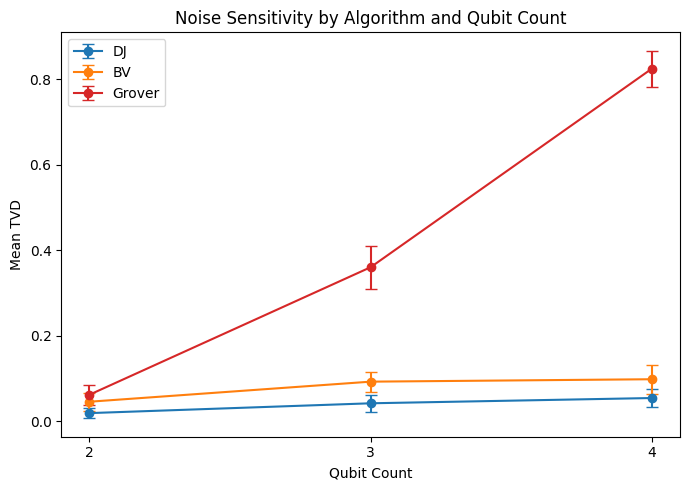

In [4]:
plt.figure(figsize=(7,5))
for algo in algorithms:
    sub = general[general.Algorithm == algo].sort_values('Qubits')
    plt.errorbar(sub['Qubits'], sub['Mean TVD'], yerr=sub['TVD Std'],
                 marker='o', capsize=4, label=algo, color=colors[algo])
plt.xlabel("Qubit Count")
plt.ylabel("Mean TVD")
plt.title("Noise Sensitivity by Algorithm and Qubit Count")
plt.xticks([2,3,4])
plt.legend()
plt.tight_layout()
plt.savefig("tvd_vs_qubits.png", dpi=150)
plt.show()

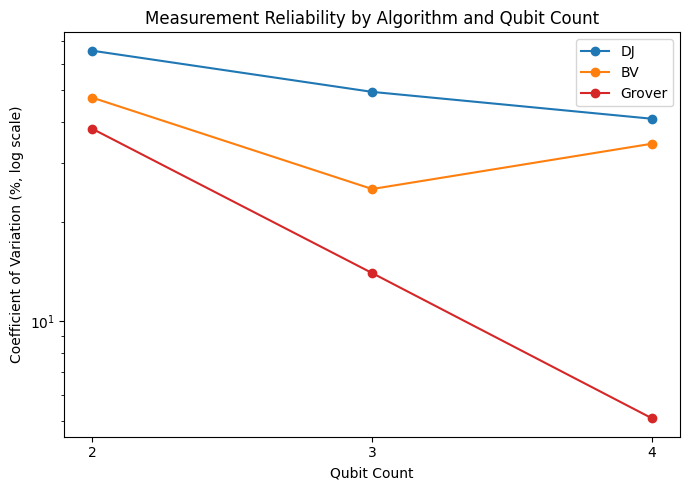

In [5]:
plt.figure(figsize=(7,5))
for algo in algorithms:
    sub = general[general.Algorithm == algo].sort_values('Qubits')
    plt.plot(sub['Qubits'], sub['CoV'], marker='o', label=algo, color=colors[algo])
plt.yscale('log')
plt.xlabel("Qubit Count")
plt.ylabel("Coefficient of Variation (%, log scale)")
plt.title("Measurement Reliability by Algorithm and Qubit Count")
plt.xticks([2,3,4])
plt.legend()
plt.tight_layout()
plt.savefig("cov_vs_qubits.png", dpi=150)
plt.show()

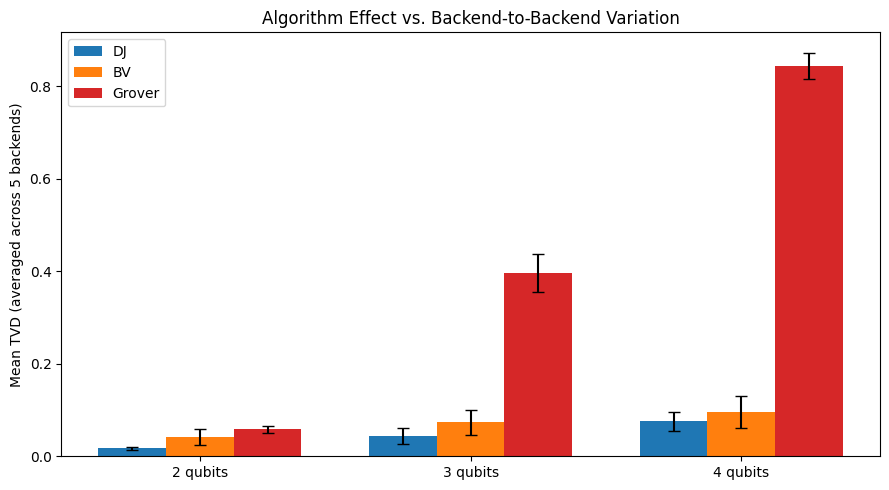

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
width = 0.25
x = np.arange(3)  # qubit counts 2,3,4

for i, algo in enumerate(algorithms):
    sub = backend[backend.Algorithm == algo]
    means = sub.groupby('Qubits')['Mean TVD'].mean().values
    stds = sub.groupby('Qubits')['Mean TVD'].std().values  # cross-backend spread
    ax.bar(x + i*width, means, width, yerr=stds, capsize=4, label=algo, color=colors[algo])

ax.set_xticks(x + width)
ax.set_xticklabels(['2 qubits','3 qubits','4 qubits'])
ax.set_ylabel("Mean TVD (averaged across 5 backends)")
ax.set_title("Algorithm Effect vs. Backend-to-Backend Variation")
ax.legend()
plt.tight_layout()
plt.savefig("backend_consistency.png", dpi=150)
plt.show()

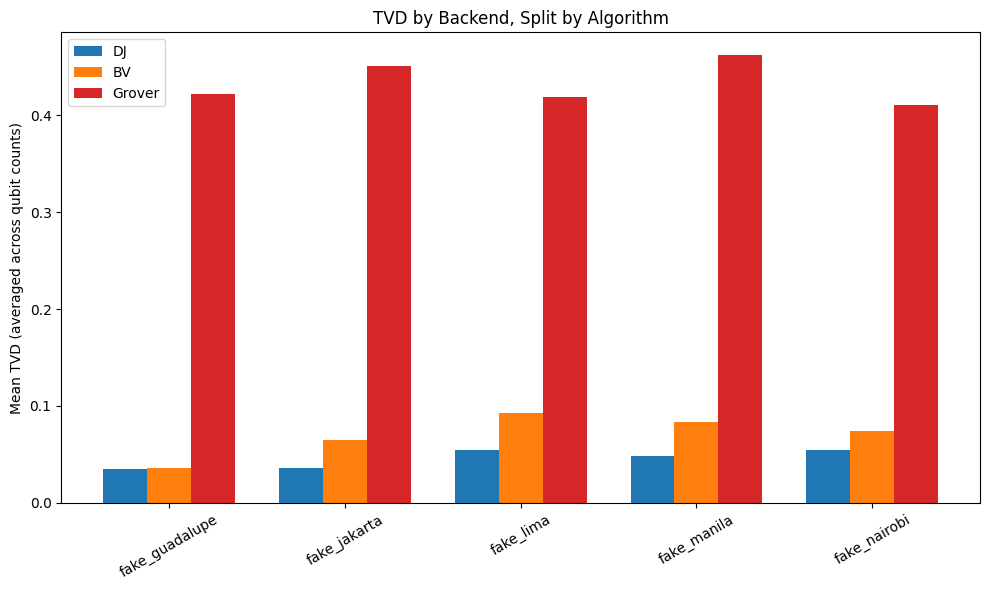

In [7]:
# ---- Plot 7: TVD by backend, split per algorithm (grouped bars) ----
backends_list = sorted(backend['Backend'].unique())
x = np.arange(len(backends_list))
width = 0.25

fig, ax = plt.subplots(figsize=(10,6))
for i, algo in enumerate(algorithms):
    sub = backend[backend.Algorithm == algo]
    # average across qubit counts per backend, so each bar summarizes one algorithm's typical TVD on that backend
    means = sub.groupby('Backend')['Mean TVD'].mean().reindex(backends_list)
    ax.bar(x + i*width, means.values, width, label=algo, color=colors[algo])

ax.set_xticks(x + width)
ax.set_xticklabels(backends_list, rotation=30)
ax.set_ylabel("Mean TVD (averaged across qubit counts)")
ax.set_title("TVD by Backend, Split by Algorithm")
ax.legend()
plt.tight_layout()
plt.savefig("tvd_by_backend_per_algorithm.png", dpi=150)
plt.show()